# 04 · Time-Series Forecasting

Forecast total government budgets using baselines (naïve, drift), **exponential smoothing**, and **ARIMA**, scored by held-out backtesting (MAPE / RMSE) via `globalbudget.forecasting`.

In [1]:
import sys
from pathlib import Path
# Locate the project root (the folder containing src/globalbudget) and add src to path.
_p = Path.cwd()
while _p != _p.parent and not (_p / "src" / "globalbudget").exists():
    _p = _p.parent
sys.path.insert(0, str(_p / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from globalbudget import data_loader, cleaning, features, viz, forecasting
viz.set_theme()
pd.set_option("display.max_columns", 40)
print("Project root:", _p)


Project root: /Users/shrutichougule/Documents/global budget


In [2]:
wide = data_loader.load_master()

## 1. Model comparison via backtesting
Hold out the last 10 years for several economies and compare models.

In [3]:
rows = []
for c in ['USA','China','India','Germany','Brazil','Japan']:
    s = forecasting.country_series(wide, c, 'Total_Budget_Billions_USD')
    tbl = forecasting.compare_models(s, test_size=10).assign(country=c)
    rows.append(tbl)
comp = pd.concat(rows, ignore_index=True)
comp.pivot(index='country', columns='model', values='MAPE_%').round(1)

model,arima,drift,ets,naive
country,,,,
Brazil,15.2,10.8,20.7,12.9
China,26.4,25.5,23.4,30.8
Germany,24.7,20.2,20.0,25.8
India,7.5,16.8,7.0,22.3
Japan,8.1,8.9,8.0,8.7
USA,25.6,26.7,21.0,30.9


In [4]:
best = comp.loc[comp.groupby('country')['MAPE_%'].idxmin(), ['country','model','MAPE_%']]
print('Best model per country (lowest MAPE):')
best.round(2).to_string(index=False)

Best model per country (lowest MAPE):


'country model  MAPE_%\n Brazil drift   10.78\n  China   ets   23.35\nGermany   ets   20.05\n  India   ets    6.98\n  Japan   ets    8.04\n    USA   ets   21.01'

## 2. Backtest fit — visualise one country
Train through 2016, predict 2017–2026, compare to actuals.

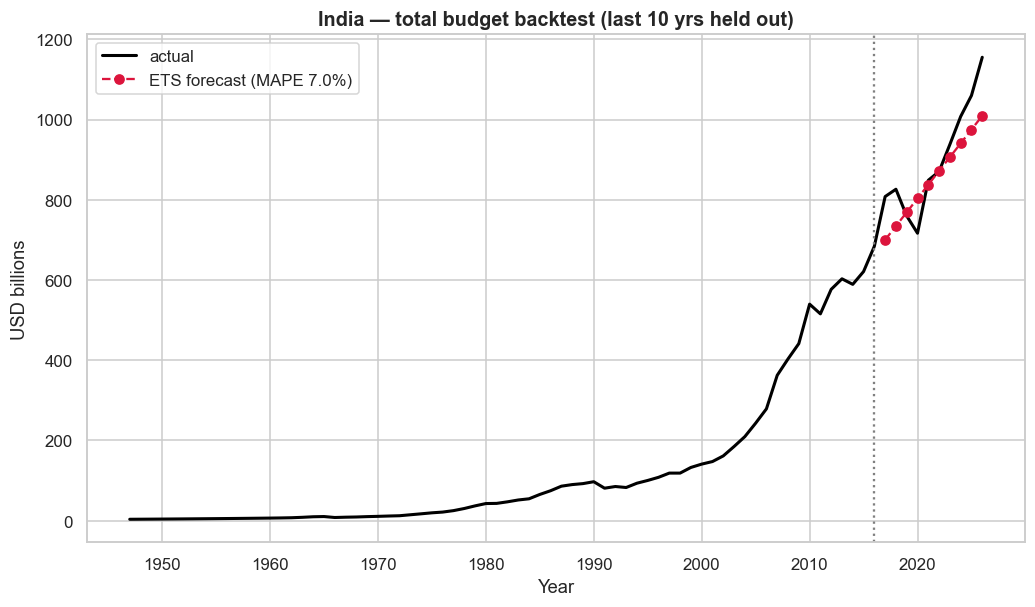

In [5]:
s = forecasting.country_series(wide, 'India', 'Total_Budget_Billions_USD')
res = forecasting.backtest(s, model='ets', test_size=10)
fig, ax = plt.subplots(figsize=(11,6))
ax.plot(s.index, s.values, label='actual', color='black', lw=2)
ax.plot(res.test_index, res.predicted, '--o', label=f'ETS forecast (MAPE {res.mape:.1f}%)', color='crimson')
ax.axvline(res.test_index[0]-1, color='gray', ls=':')
ax.set_title('India — total budget backtest (last 10 yrs held out)')
ax.set_xlabel('Year'); ax.set_ylabel('USD billions'); ax.legend()
viz.save(fig, 'forecast_backtest_india'); plt.show()

## 3. Forecast into the future
Fit on the full series and project the next 10 years.

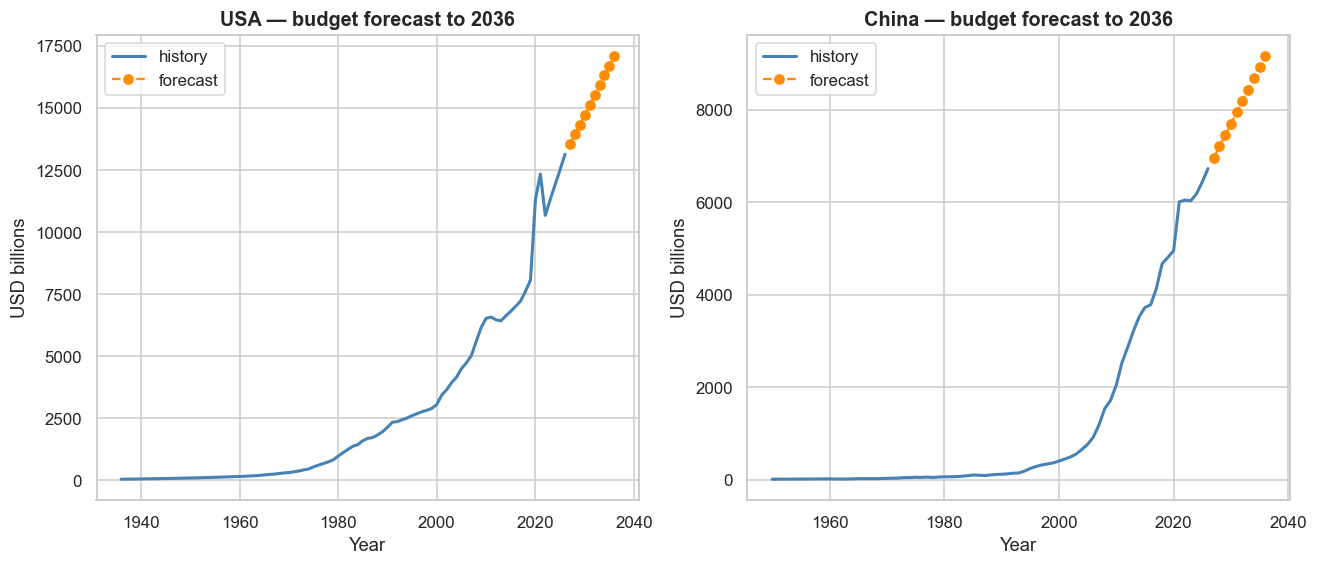

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,5.5))
for ax, c in zip(axes, ['USA','China']):
    s = forecasting.country_series(wide, c, 'Total_Budget_Billions_USD')
    fc = forecasting.forecast_future(s, horizon=10, model='ets')
    ax.plot(s.index, s.values, label='history', color='steelblue', lw=2)
    ax.plot(fc.index, fc.values, '--o', label='forecast', color='darkorange')
    ax.set_title(f'{c} — budget forecast to {int(fc.index[-1])}'); ax.set_xlabel('Year'); ax.set_ylabel('USD billions'); ax.legend()
viz.save(fig, 'forecast_future_usa_china'); plt.show()

## 4. Forecasting a category amount
The same machinery works on any numeric series — here US health spending (USD).

In [7]:
s = forecasting.country_series(wide, 'USA', 'Health_Amount_Billions_USD')
print(forecasting.compare_models(s, test_size=10).round(2).to_string(index=False))
fc = forecasting.forecast_future(s, horizon=10, model='ets')
print('\nUSA health-spend forecast (USD bn):')
print(fc.round(1).to_string())

model  MAPE_%   RMSE
  ets   16.24 521.02
arima   23.76 751.90
drift   27.29 838.26
naive   31.47 957.72

USA health-spend forecast (USD bn):
2027    3138.5
2028    3254.0
2029    3369.5
2030    3484.9
2031    3600.4
2032    3715.9
2033    3831.4
2034    3946.9
2035    4062.4
2036    4177.9


**Notes.** ETS and ARIMA generally beat the naïve/drift baselines; MAPE rises for economies with structural breaks (currency regime changes, rebasing). Forecasts are trend extrapolations of nominal USD and should be read as scenarios, not predictions. Next: **05_machine_learning**.